|<div style="width:330px"><img src="https://www.ufz.de/static/custom/weblayout/DefaultInternetLayout/img/logos/ufz_transparent_de_blue.png" width="300"/></div>|<div style="width:290px"><img src="https://discourse.opengeosys.org/uploads/default/original/1X/a288c27cc8f73e6830ad98b8729637a260ce3490.png" width="290"/></div>|<div style="width:330px"><img src="https://github.com/nagelt/Teaching_Scripts/raw/9d9e29ecca4b04eaf7397938eacbf116d37ddc93/Images/TUBAF_Logo_blau.png" width="300"/></div>|
|---|---|--:|

Dr. Mehran Ghasabeh
\
Prof. Dr. Thomas Nagel

*Chair of Soil Mechanics and Foundation Engineering  
Geotechnical Institute  
Technische Universität Bergakademie Freiberg*

https://tu-freiberg.de/en/soilmechanics

# Tunnel Convergence Problem
## Solving Kirsch's Problem Using the Release Nodal Force Approach

### 1. Introduction

Tunnel excavation induces a redistribution of the in-situ stress field around the opening, resulting in deformation of the surrounding rock mass and inward displacement of the tunnel boundary. This deformation, commonly referred to as tunnel convergence, is an important quantity in the design and assessment of underground structures. Its magnitude and spatial distribution depend on several factors, including the initial stress state, tunnel geometry, constitutive behaviour of the surrounding material, and the support or internal pressure acting on the excavation boundary.

In this example, a two-dimensional tunnel convergence problem is simulated using OpenGeoSys (OGS). The problem is formulated under plane-strain conditions and represents a circular tunnel embedded in a homogeneous rock mass subjected to an initially uniform far-field stress. Tunnel excavation is represented by progressively reducing the pressure acting on the excavation boundary, thereby reproducing the stress release associated with material removal. The numerical results are then verified against the analytical solutions obtained using the Kirsch solution. The Kirsch solution provides an the classic closed-form elastic analytical solution for stresses and radial displacements (convergence) around a circular opening
an infinite, homogeneous, isotropic, linear-elastic medium and is therefore a useful benchmark for numerical excavation models.

This notebook models a two-dimensional quarter section of a circular tunnel with a radius of $6.5\,\mathrm{m}$. A vertical compressive far-field stress of $20\,\mathrm{MPa}$ is applied, while symmetry boundary conditions are imposed along the left and bottom boundaries. The right boundary is traction-free, consistent with the uniaxial vertical far-field stress assumed for this verification benchmark.

Two modelling approaches are compared:

1. **Release nodal force approach:** the rock mass is initialized with an in-situ stress field, and the equivalent nodal forces acting at the tunnel wall are gradually released to represent excavation.
2. **Standard approach:** the tunnel is present from the beginning, and the external load is applied directly to an initially unstressed model.

Both approaches are evaluated using linear and quadratic finite elements. The computed stress distribution along the $\theta=0^\circ$ axis is compared with the analytical Kirsch solution, with particular attention given to the accuracy near the tunnel wall.


#### **Release nodal force boundary condition**

This boundary condition applies a time-dependent *release nodal force* to the nodes of the boundary mesh on which it is defined, here the tunnel wall (`arc`). It is the numerical counterpart of the excavation process: instead of removing elements, the forces that the excavated material exerted on the remaining rock mass are gradually withdrawn.

##### Finite-element formulation

The small-deformation process solves the discrete equilibrium equations

$$
\boldsymbol{r}(\boldsymbol{u},t) \;=\; \boldsymbol{F}^{\mathrm{int}}(\boldsymbol{u}) - \boldsymbol{F}^{\mathrm{ext}}(t) \;=\; \boldsymbol{0},
\qquad
\boldsymbol{F}^{\mathrm{int}}(\boldsymbol{u}) \;=\; \int_{\Omega} \mathbf{B}^{\mathrm{T}}\,\boldsymbol{\sigma}\,\mathrm{d}\Omega ,
$$

where $\mathbf{B}$ is the strain–displacement matrix and $\boldsymbol{F}^{\mathrm{ext}}$ collects the applied loads (here the far-field traction on the top boundary). With the process initialized by the in-situ stress, the total stress is

$$
\boldsymbol{\sigma} \;=\; \boldsymbol{\sigma}_0 + \mathbb{C} : \boldsymbol{\varepsilon}(\boldsymbol{u}),
$$

with $\boldsymbol{\sigma}_0$ the in-situ stress (here a uniaxial vertical compression of $20\,\mathrm{MPa}$) and $\mathbb{C}$ the elasticity tensor.

**Step 1 — non-equilibrium initial residual.** At $t=0$, with $\boldsymbol{u}_0 = \boldsymbol{0}$, the domain containing the (traction-free) opening is *not* in equilibrium under $\boldsymbol{\sigma}_0$. OGS assembles this initial out-of-balance force once:

$$
\boldsymbol{r}^{\mathrm{neq}}
\;=\; \boldsymbol{r}(\boldsymbol{u}_0, 0)
\;=\; \int_{\Omega} \mathbf{B}^{\mathrm{T}}\,\boldsymbol{\sigma}_0\,\mathrm{d}\Omega \;-\; \boldsymbol{F}^{\mathrm{ext}}(0).
$$

The vector $\boldsymbol{r}^{\mathrm{neq}}$ is called the **non-equilibrium initial residual**: the out-of-balance nodal force vector obtained by evaluating the equilibrium equations for the *undeformed* initial state. It is non-zero because a stress field that was in equilibrium in the intact ground is no longer in equilibrium in a domain containing the opening — at the traction-free tunnel wall nothing pushes back against $\boldsymbol{\sigma}_0$. Assembling $\int_\Omega \mathbf{B}^{\mathrm{T}}\boldsymbol{\sigma}_0\,\mathrm{d}\Omega$ node by node:

- at **interior nodes**, the contributions of neighbouring elements cancel — the entries vanish;
- at the **outer boundaries**, the internal forces are balanced by the applied tractions and support reactions (top load, symmetry conditions) — the entries vanish as well;
- at the **tunnel wall nodes**, nothing cancels them — the remaining entries are exactly the *equivalent nodal forces* that the excavated core exerted on the tunnel wall,

$$
F_{0,i} \;=\; r^{\mathrm{neq}}_i
\;=\; \int_{\Gamma_{\mathrm{arc}}} N_i \,\big(\boldsymbol{\sigma}_0\cdot\boldsymbol{n}\big)\,\mathrm{d}\Gamma ,
\qquad i \in \text{nodes of } \Gamma_{\mathrm{arc}},
$$

with $N_i$ the nodal shape function and $\boldsymbol{n}$ the outward normal of the wall. The `ReleaseNodalForce` boundary condition stores these values $F_{0,i}$ for every node of its boundary mesh. This step requires `<compensate_non_equilibrium_initial_residuum>true</compensate_non_equilibrium_initial_residuum>` on the process variable, since $\boldsymbol{r}^{\mathrm{neq}}$ is only computed (and kept) for compensated variables.

**Step 2 — compensation (in-situ equilibrium).** In every time step the solver subtracts the stored initial residual from the assembled one,

$$
\tilde{\boldsymbol{r}}(\boldsymbol{u},t) \;=\; \boldsymbol{r}(\boldsymbol{u},t) - \boldsymbol{r}^{\mathrm{neq}} ,
$$

so that at $t=0$ the model is exactly in equilibrium with $\boldsymbol{\sigma}_0$ and $\boldsymbol{u}=\boldsymbol{0}$: the compensation acts like a support force $\boldsymbol{F}_0$ that still holds the tunnel wall in place — the not-yet-excavated state.

**Step 3 — time-dependent release.** The boundary condition then adds, as a natural (Neumann-type) contribution at each wall degree of freedom $i$, the load

$$
b_i \;\mathrel{+}=\; -\big(1 - f(t)\big)\, F_{0,i} ,
$$

which, combined with Step 2, gives the effective residual at the wall nodes

$$
\tilde{r}_i(\boldsymbol{u},t)
\;=\; F^{\mathrm{int}}_i(\boldsymbol{u}) - F^{\mathrm{ext}}_i(t) - f(t)\,F_{0,i}
\;=\; 0 .
$$

The wall is therefore supported by the fictitious force $f(t)\,\boldsymbol{F}_0$, controlled by the user-defined *time-decay function* $f(t)$:

- at $t = 0$: $f = 1$, the full in-situ support acts, $\boldsymbol{u} = \boldsymbol{0}$ (no deformation);
- for $0 < t < t_\mathrm{e}$: partial release — equivalent to a fictitious internal support pressure $p(t) = f(t)\,p_0$ on the wall;
- at $t \ge t_\mathrm{e}$: $f = 0$, the wall is completely unloaded (traction-free) — the fully excavated, unsupported tunnel of the Kirsch problem.

##### Decay function used here

A linear decay over the excavation duration $t_\mathrm{e} = 2\,\mathrm{d} = 1.728\times 10^{5}\,\mathrm{s}$ is used:

$$
f(t) =
\begin{cases}
1 - \dfrac{t}{t_\mathrm{e}}, & 0 \le t \le t_\mathrm{e},\\[6pt]
0, & t > t_\mathrm{e}.
\end{cases}
$$

##### Project-file definition

In the project file, the boundary condition is defined on the process variable `displacement` as:

```xml
<boundary_condition>
    <mesh>arc</mesh>
    <type>ReleaseNodalForce</type>
    <time_decay_parameter>decay_function</time_decay_parameter>
</boundary_condition>
```

where `decay_function` is a `Function`-type parameter implementing $f(t)$ above. Note that this approach requires the process to be initialized with the in-situ stress (`<initial_stress>`), since the release forces $\boldsymbol{F}_0$ are computed from it, and the process variable must enable `compensate_non_equilibrium_initial_residuum`.


In [1]:
import os
from pathlib import Path
import shutil
import sys

import gmsh
import matplotlib.pyplot as plt
import numpy as np
import ogstools as ot
from build_tunnel_prj import (
    EXCAVATION_DURATION,
    VERTICAL_STRESS,
    build_kirsch_project,
)
from mesh_tunnel import MeshGenerator

In [2]:
# Set this to True only when you intentionally want to erase all generated files.
reset_generated_folders = False

if reset_generated_folders:
    for folder in [Path("_out"), Path("_prj")]:
        if folder.is_dir():
            shutil.rmtree(folder)
            print(f"Deleted: {folder}")

In [3]:
out_dir = Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out"))
if not out_dir.exists():
    out_dir.mkdir(parents=True)
    print(f"Created: {out_dir}")
mesh_dir_quad = Path("input_meshes_quadratic")
mesh_dir_line = Path("input_meshes_linear")
# create prj directory if it does not exist
prj_dir = Path("_prj")
if not prj_dir.exists():
    prj_dir.mkdir(parents=True)
    print(f"Created: {prj_dir}")

# 3. Mesh generation
## 3.1 Model with linear element

In [4]:
if not gmsh.isInitialized():
    gmsh.initialize(readConfigFiles=False)
gmsh.model.add(mesh_dir_quad.name)
mesh_generator = MeshGenerator(gmsh_model=gmsh.model)
mesh_generator.generate_meshes(out_dir=mesh_dir_quad, order=2)

gmsh.finalize()

INFO:ogstools.meshes.gmsh_converter:Detected domain dimension of 2
INFO:ogstools.meshes.gmsh_converter:Found material IDs: [1]
INFO:ogstools.meshes.gmsh_converter:Renumbered to: [0]
INFO:ogstools.meshes.gmsh_converter:domain: UnstructuredGrid (0x767dcf710a60)
  N Cells:    2800
  N Points:   2921
  X Bounds:   0.000e+00, 7.000e+01
  Y Bounds:   -8.570e+02, -7.870e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   1


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 20%] Meshing curve 5 (Line)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 30%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 40%] Meshing curve 9 (Line)
Info    : [ 50%] Meshing curve 10 (Line)
Info    : [ 50%] Meshing curve 11 (Line)
Info    : [ 60%] Meshing curve 12 (Line)
Info    : [ 60%] Meshing curve 13 (Line)
Info    : [ 60%] Meshing curve 14 (Line)
Info    : [ 70%] Meshing curve 15 (Line)
Info    : [ 70%] Meshing curve 16 (Line)
Info    : [ 80%] Meshing curve 17 (Circle)
Info    : [ 80%] Meshing curve 18 (Circle)
Info    : [ 90%] Meshing curve 19 (Circle)
Info    : [ 90%] Meshing curve 20 (Circle)
Info    : [100%] Meshing curve 21 (Line)
Info    : [100%] Meshing curve 22 (Line)
Info    : Done meshing 1D (Wall 0.000490714s, CPU 0.000951s)
Info    : Mesh

INFO:ogstools.meshes.gmsh_converter:bottom: UnstructuredGrid (0x767dcf711060)
  N Cells:    60
  N Points:   61
  X Bounds:   6.500e+00, 7.000e+01
  Y Bounds:   -8.570e+02, -8.570e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   2
INFO:ogstools.meshes.gmsh_converter:left: UnstructuredGrid (0x767d9051a8c0)
  N Cells:    60
  N Points:   61
  X Bounds:   0.000e+00, 0.000e+00
  Y Bounds:   -8.505e+02, -7.870e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   2
INFO:ogstools.meshes.gmsh_converter:right: UnstructuredGrid (0x767d9051ae60)
  N Cells:    40
  N Points:   41
  X Bounds:   7.000e+01, 7.000e+01
  Y Bounds:   -8.570e+02, -7.870e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   2
INFO:ogstools.meshes.gmsh_converter:top: UnstructuredGrid (0x767d9051b040)
  N Cells:    40
  N Points:   41
  X Bounds:   0.000e+00, 7.000e+01
  Y Bounds:   -7.870e+02, -7.870e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   2
INFO:ogstools.meshes.gmsh_converter:arc: UnstructuredGrid (0x767d9

domain: 2800 cells
bottom: 60 cells
left: 60 cells
right: 40 cells
top: 40 cells
arc: 40 cells
info: Reordering nodes... 
info: Method: Reversing order of nodes unless it is considered correct by the OGS6 standard, i.e. such that det(J) > 0, where J is the Jacobian of the global-to-local coordinate transformation.
info: Corrected 0 elements.
info: VTU file written.
Create quadratic mesh for input_meshes_quadratic/left.vtu
info: Create a quadratic order mesh
info: Save the new mesh into a file
Create quadratic mesh for input_meshes_quadratic/arc.vtu
info: Create a quadratic order mesh
info: Save the new mesh into a file
Create quadratic mesh for input_meshes_quadratic/right.vtu
info: Create a quadratic order mesh
info: Save the new mesh into a file
Create quadratic mesh for input_meshes_quadratic/bottom.vtu
info: Create a quadratic order mesh
info: Save the new mesh into a file
Create quadratic mesh for input_meshes_quadratic/domain.vtu
info: Create a quadratic order mesh
info: Save the

In [5]:
if not gmsh.isInitialized():
    gmsh.initialize(readConfigFiles=False)
gmsh.model.add(mesh_dir_quad.name)
mesh_generator = MeshGenerator(gmsh_model=gmsh.model)
mesh_generator.generate_meshes(out_dir=mesh_dir_line, order=1)

gmsh.finalize()

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 20%] Meshing curve 5 (Line)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 30%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 40%] Meshing curve 9 (Line)
Info    : [ 50%] Meshing curve 10 (Line)
Info    : [ 50%] Meshing curve 11 (Line)
Info    : [ 60%] Meshing curve 12 (Line)
Info    : [ 60%] Meshing curve 13 (Line)
Info    : [ 60%] Meshing curve 14 (Line)
Info    : [ 70%] Meshing curve 15 (Line)
Info    : [ 70%] Meshing curve 16 (Line)
Info    : [ 80%] Meshing curve 17 (Circle)
Info    : [ 80%] Meshing curve 18 (Circle)
Info    : [ 90%] Meshing curve 19 (Circle)
Info    : [ 90%] Meshing curve 20 (Circle)
Info    : [100%] Meshing curve 21 (Line)
Info    : [100%] Meshing curve 22 (Line)
Info    : Done meshing 1D (Wall 0.000473027s, CPU 0.000873s)
Info    : Mesh

INFO:ogstools.meshes.gmsh_converter:Detected domain dimension of 2
INFO:ogstools.meshes.gmsh_converter:Found material IDs: [1]
INFO:ogstools.meshes.gmsh_converter:Renumbered to: [0]
INFO:ogstools.meshes.gmsh_converter:domain: UnstructuredGrid (0x767d9051b5e0)
  N Cells:    2800
  N Points:   2921
  X Bounds:   0.000e+00, 7.000e+01
  Y Bounds:   -8.570e+02, -7.870e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   1
INFO:ogstools.meshes.gmsh_converter:bottom: UnstructuredGrid (0x767d9051bb80)
  N Cells:    60
  N Points:   61
  X Bounds:   6.500e+00, 7.000e+01
  Y Bounds:   -8.570e+02, -8.570e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   2
INFO:ogstools.meshes.gmsh_converter:left: UnstructuredGrid (0x767d9051a440)
  N Cells:    60
  N Points:   61
  X Bounds:   0.000e+00, 0.000e+00
  Y Bounds:   -8.505e+02, -7.870e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   2
INFO:ogstools.meshes.gmsh_converter:right: UnstructuredGrid (0x767d9051a560)
  N Cells:    40
  N Points:   41


domain: 2800 cells
bottom: 60 cells
left: 60 cells
right: 40 cells
top: 40 cells
arc: 40 cells
info: Reordering nodes... 
info: Method: Reversing order of nodes unless it is considered correct by the OGS6 standard, i.e. such that det(J) > 0, where J is the Jacobian of the global-to-local coordinate transformation.
info: Corrected 0 elements.
info: VTU file written.
info: Mesh reading time: 0.0031216 s
info: MeshNodeSearcher construction time: 8.0764e-05 s
info: identifySubdomainMesh(): identifySubdomainMeshNodes took 0.00017529 s
info: identifySubdomainMesh(): identifySubdomainMeshElements took 0.00911148 s
info: identifySubdomainMesh(): identifySubdomainMeshNodes took 9.031e-06 s
info: There is already a 'bulk_node_ids' property present in the subdomain mesh 'bottom' and it is equal to the newly computed values.
info: identifySubdomainMesh(): identifySubdomainMeshElements took 0.00487714 s
info: There is already a 'bulk_element_ids' property present in the subdomain mesh 'bottom' and 

In [6]:
kirsch_project_file = Path("kirsch.prj")
prj = build_kirsch_project(
    output_file=kirsch_project_file,
    mesh_dir=Path(),  # mesh files are selected through ot.Model / OGS -m
    element_order=2,
)

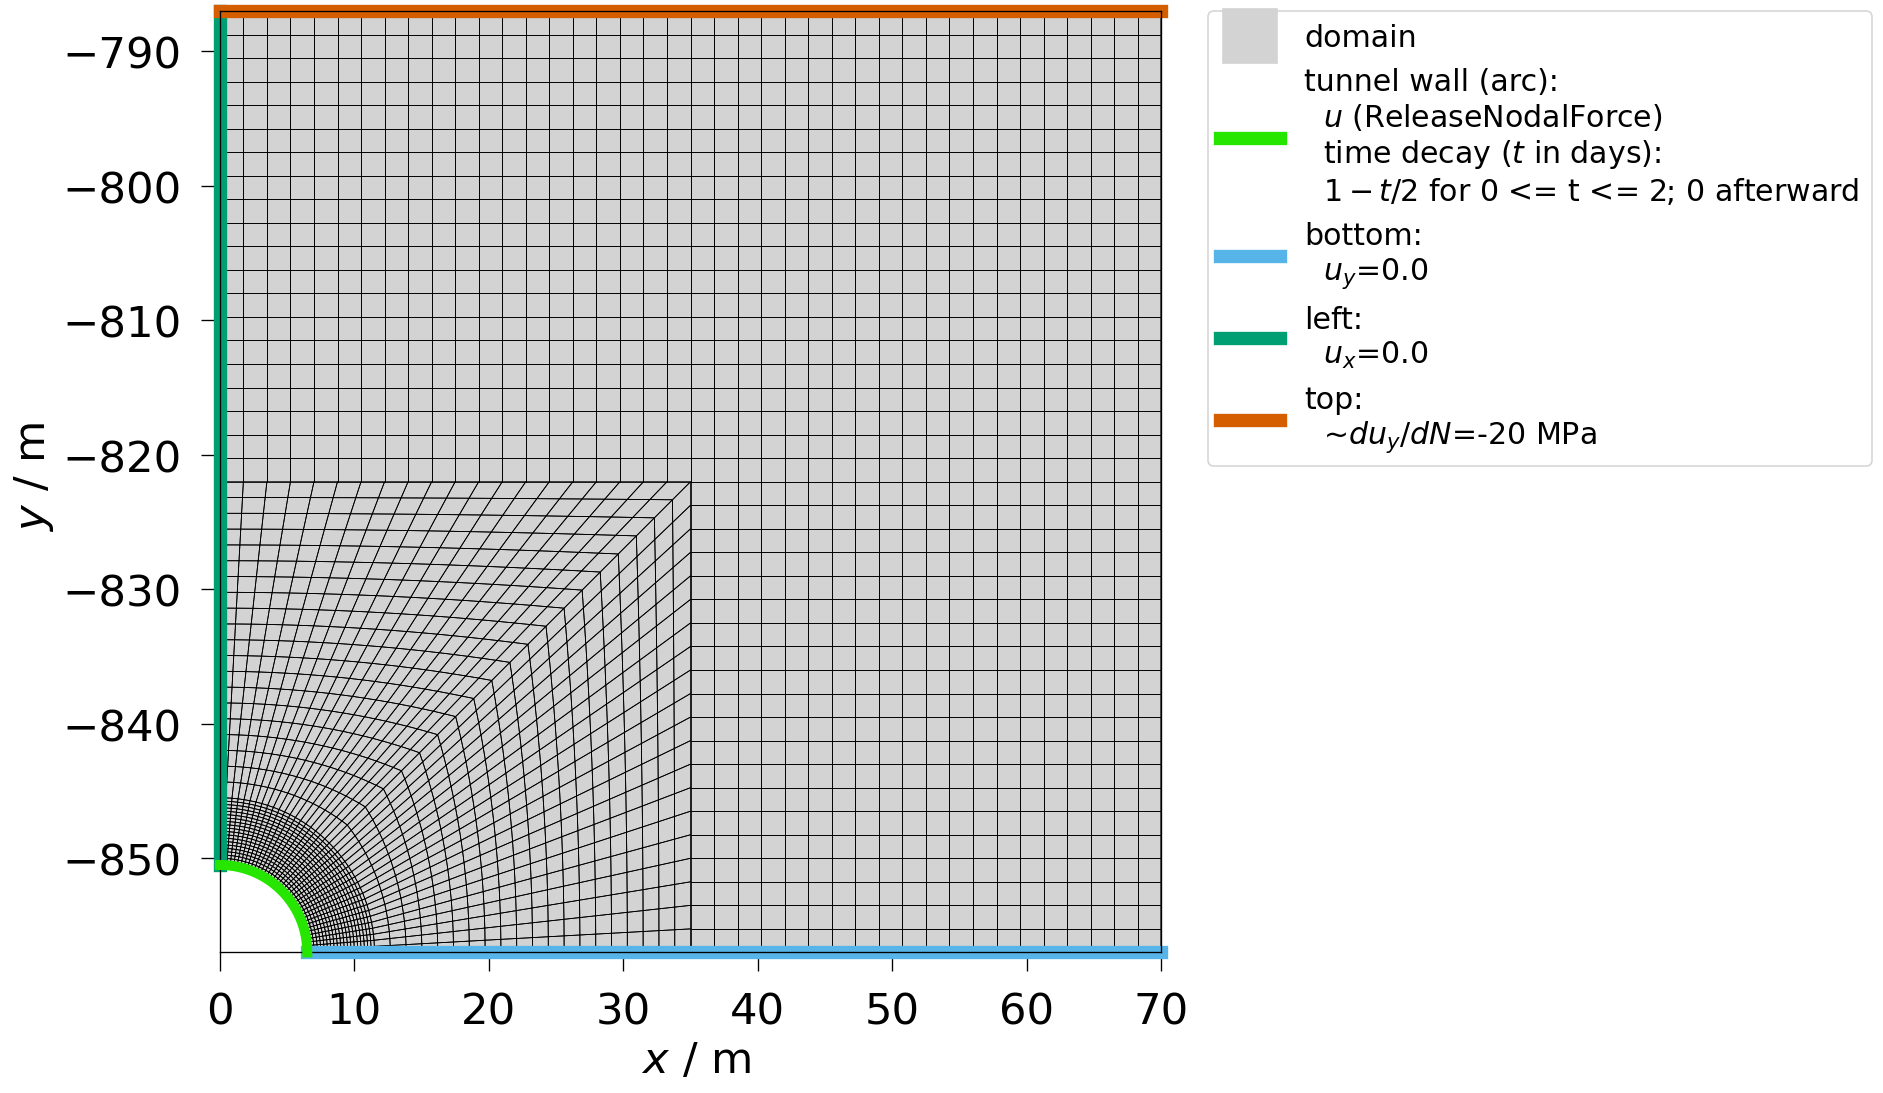

In [7]:
m = ot.Model(
    project=prj,
    meshes=mesh_dir_quad,
)

colors = {
    "arc": "#26E600",
    "bottom": "#56B4E9",
    "left": "#009E73",
    "right": "#CC79A7",  # appears only if it has an explicit BC
    "top": "#D55E00",
}

fig = m.plot_constraints(figsize=(16, 9), fontsize=26, leg_fontsize=18)
ax = fig.axes[0]

# Change boundary colors and emphasize the tunnel wall.
for line in ax.lines:
    name = line.get_label().split(":", 1)[0]
    if name in colors:
        line.set_color(colors[name])
    if name == "arc":
        line.set_linewidth(6)
        line.set_zorder(10)

# Display the project values in engineering units in this figure.
excavation_duration_days = EXCAVATION_DURATION / (24 * 60 * 60)
vertical_stress_mpa = VERTICAL_STRESS / 1.0e6

# Change matching legend colors and replace the raw SI values.
legend = ax.get_legend()
for handle, text in zip(legend.legend_handles, legend.get_texts()):
    name = text.get_text().split(":", 1)[0]
    if name in colors:
        handle.set_color(colors[name])
    label = text.get_text()
    if name == "arc":
        label = (
            "tunnel wall (arc):\n"
            "  $u$ (ReleaseNodalForce)\n"
            "  time decay ($t$ in days):\n"
            f"  $1-t/{excavation_duration_days:g}$ for "
            f"0 <= t <= {excavation_duration_days:g}; "
            "0 afterward"
        )
    elif name == "top":
        label = label.replace(
            f"-{VERTICAL_STRESS}", f"-{vertical_stress_mpa:g} MPa"
        )
    text.set_text(label)

#### 4. Computation

In [8]:
def runBenchmark(
    project_file,
    out_dir,
    prj_dir,
    output_prefix,
    mesh_dir,
    order=2,
    standard_approach=False,
    use_element_deactivation=False,
    ogs_path=None,
):
    prj = ot.Project(
        input_file=project_file,
        output_file=Path(prj_dir, f"{output_prefix}.prj"),
    )

    xpath_var = './process_variables/process_variable[name="displacement"]/'
    prj.replace_text(
        order,
        xpath=xpath_var + "order",
    )

    prj.replace_text(
        output_prefix,
        xpath="./time_loop/output/prefix",
    )

    if standard_approach:
        prj.replace_text(
            "false",
            xpath=xpath_var + "compensate_non_equilibrium_initial_residuum",
        )
        prj.remove_element(
            xpath=xpath_var + 'boundary_conditions/boundary_condition[mesh="arc"]'
        )
        prj.remove_element(xpath="./processes/process/initial_stress")

        prj.remove_element(xpath="./time_loop/processes/process/time_stepping")
        prj.time_loop.set_stepping(
            process="SD",
            type="FixedTimeStepping",
            t_initial="0",
            t_end="1",
            repeat="1",
            delta_t="1.0",
        )

    if use_element_deactivation:
        prj.add_block(
            blocktag="deactivated_subdomains",
            parent_xpath="./process_variables/process_variable",
        )
        prj.add_block(
            blocktag="deactivated_subdomain",
            parent_xpath="./process_variables/process_variable/deactivated_subdomains",
            taglist=["time_interval", "material_ids"],
            textlist=["", "1"],
        )
        prj.add_element(
            parent_xpath="./process_variables/process_variable/deactivated_subdomains/deactivated_subdomain/time_interval",
            tag="start",
            text="0",
        )
        prj.add_element(
            parent_xpath="./process_variables/process_variable/deactivated_subdomains/deactivated_subdomain/time_interval",
            tag="end",
            text="1e+18",
        )

    prj.write_input()

    # Use the OGS executable installed next to the active notebook kernel.
    # Path.resolve() is intentionally avoided because a venv Python may be a
    # symlink to the system interpreter.
    venv_bin = Path(sys.executable).parent
    execution = ot.Execution(
        ogs_path=str(ogs_path or venv_bin),
        omp_num_threads=4,
        ogs_asm_threads=4,
        write_logs=True,
    )

    ogs_executable = Path(execution.ogs_path) / "ogs"
    if not ogs_executable.is_file():
        raise FileNotFoundError(
            f"OGS was not found in the active virtual environment: {ogs_executable}"
        )

    model = ot.Model(project=prj, meshes=mesh_dir, execution=execution)
    simulation = model.run(
        target=Path(out_dir, output_prefix),
        overwrite=True,
    )

    print(f"Output prefix is {output_prefix}")
    print(f"OGS executable: {ogs_executable}")

    return simulation.meshseries_file

##### 4.1. Release nodal force approach

In [9]:
# This generated project contains the initial stress, arc release, and
# time-decay configuration used by the ReleaseNodalForce simulation.
release_project_file = kirsch_project_file
pvd = runBenchmark(
    project_file=release_project_file,
    out_dir=out_dir,
    prj_dir=prj_dir,
    output_prefix="kirsch",
    mesh_dir=mesh_dir_quad,
)

 ogs -o _out -m input_meshes_quadratic _prj/kirsch.prj
['ogs', '-o', '_out', '-m', 'input_meshes_quadratic', '_prj/kirsch.prj']
Output prefix is kirsch


In [10]:
ms = ot.MeshSeries(pvd).scale(time="d")
ms_last = ms[-1]
xs = np.asarray(list(np.linspace(6.5, 70.0, 35)))
probes = np.asarray([[i, -857.0, 0] for i in xs])  #  all probes are along the x_axis
extracted_ms = ot.MeshSeries.probe(ms, probes)

100%|██████████| 22/22 [00:00<00:00, 48.19it/s]


In [11]:
pvd_linear = runBenchmark(
    project_file=release_project_file,
    out_dir=out_dir,
    prj_dir=prj_dir,
    output_prefix="kirsch_linear_e",
    mesh_dir=mesh_dir_line,
    order=1,
)

 ogs -o _out -m input_meshes_linear _prj/kirsch_linear_e.prj
['ogs', '-o', '_out', '-m', 'input_meshes_linear', '_prj/kirsch_linear_e.prj']
Output prefix is kirsch_linear_e


In [12]:
ms_linear = ot.MeshSeries(pvd_linear).scale(time="d")
extracted_ms_linear = ot.MeshSeries.probe(ms_linear, probes)

100%|██████████| 22/22 [00:00<00:00, 123.49it/s]


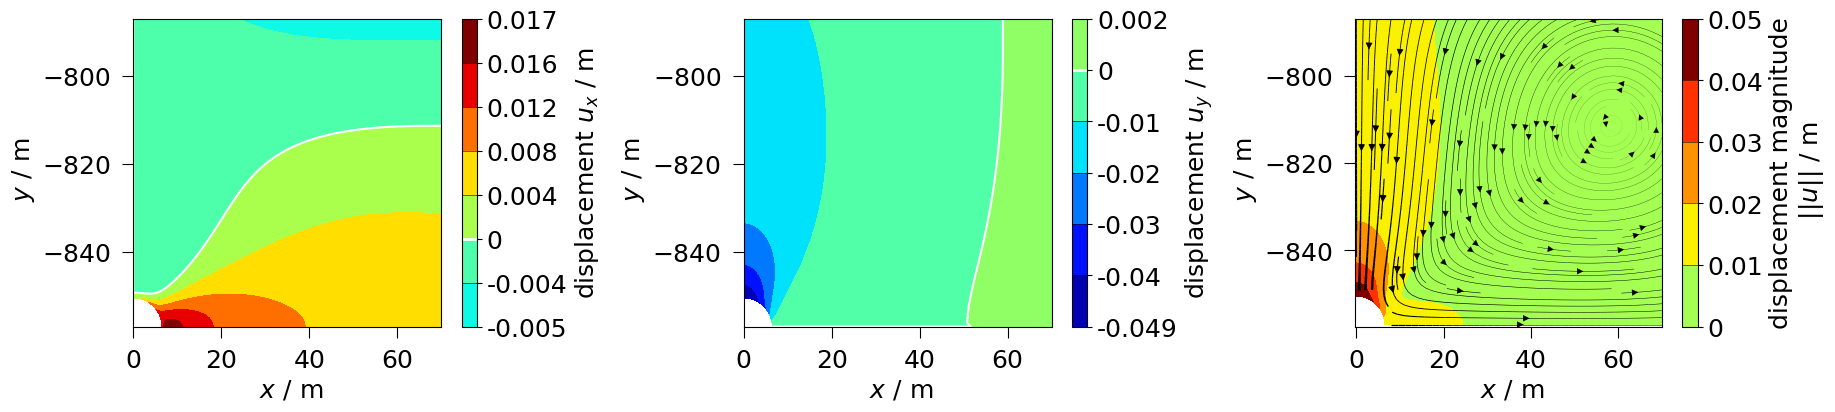

In [13]:
ot.plot.setup.num_levels = 6
u = ot.variables.displacement
fig, ax = plt.subplots(1, 3, figsize=(21, 4), gridspec_kw={"wspace": 0.5})
for axis, variable in zip(ax, [u["x"], u["y"], u]):
    ot.plot.contourf(
        ms_last,
        variable,
        fig=fig,
        ax=axis,
        fontsize=18,
        cb_labelsize=18,
        cmap="jet",
    )

cb_length, cb_width = 1.0, 1.0  # fractions of the default colorbar size
for cax in [a for a in fig.axes if a.get_label() == "<colorbar>"]:
    p = cax.get_position()
    h = p.height * cb_length
    cax.set_position([p.x0, p.y0 + 0.5 * (p.height - h), p.width * cb_width, h])

plt.show()

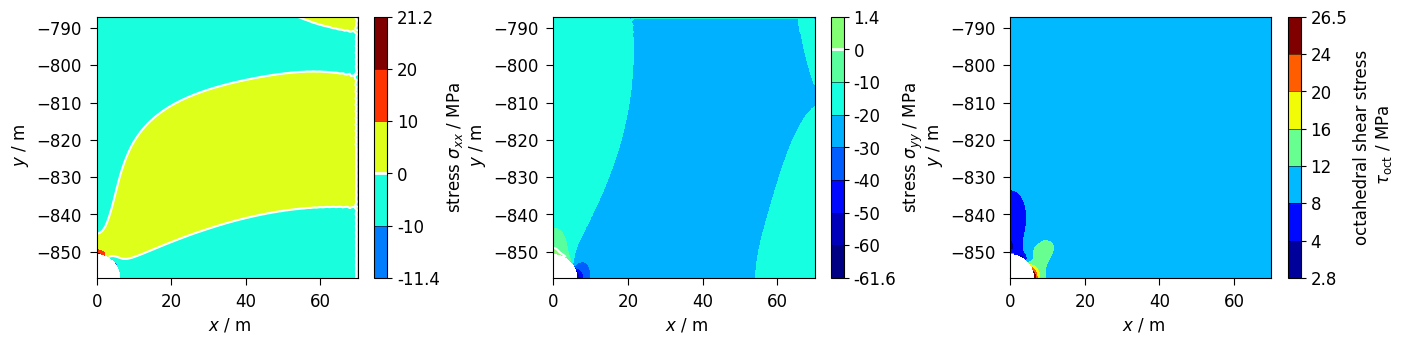

In [14]:
u = ot.variables.stress
fig, ax = plt.subplots(1, 3, figsize=(16, 4), gridspec_kw={"wspace": 0.4})
for axis, variable in zip(ax, [u["xx"], u["yy"], u.octahedral_shear]):
    ot.plot.contourf(
        ms_last,
        variable,
        fig=fig,
        ax=axis,
        fontsize=12,
        cb_labelsize=12,
        cmap="jet",
    )

fig.canvas.draw()  # finalize the axes positions before aligning colorbars
colorbar_axes = [
    axis for axis in fig.axes if axis.get_label() == "<colorbar>"
]
for plot_axis, colorbar_axis in zip(ax, colorbar_axes):
    plot_pos = plot_axis.get_position()
    bar_pos = colorbar_axis.get_position()
    colorbar_axis.set_position(
        [bar_pos.x0, plot_pos.y0, bar_pos.width, plot_pos.height]
    )

plt.show()

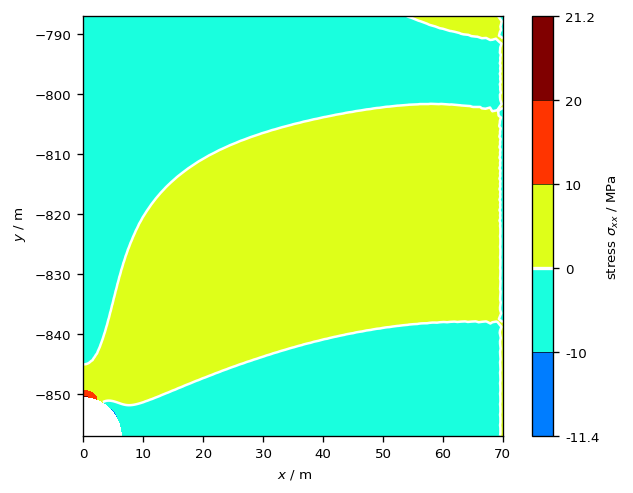

In [15]:
fig = ot.plot.contourf(
    ms_last, ot.variables.stress["xx"], figsize=(6, 4), fontsize=8, cmap="jet"
)

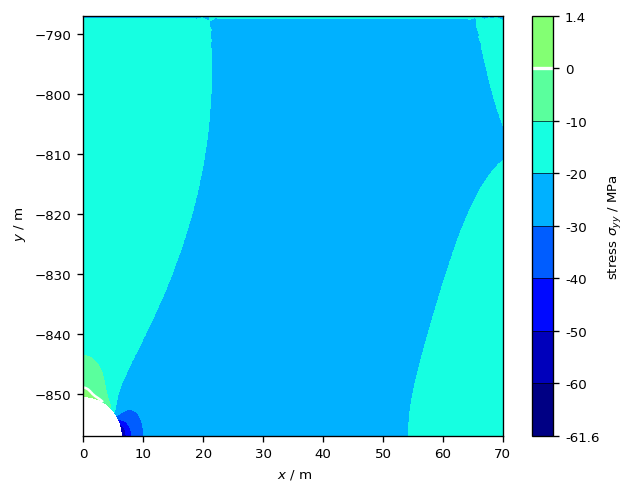

In [16]:
fig = ot.plot.contourf(
    ms_last, ot.variables.stress["yy"], figsize=(6, 4), fontsize=8, cmap="jet"
)

##### 4.2. Standard approach

In [17]:
pvd_std = runBenchmark(
    project_file=release_project_file,
    out_dir=out_dir,
    prj_dir=prj_dir,
    output_prefix="kirsch_standard",
    mesh_dir=mesh_dir_quad,
    order=2,
    standard_approach=True,
)

 ogs -o _out -m input_meshes_quadratic _prj/kirsch_standard.prj
['ogs', '-o', '_out', '-m', 'input_meshes_quadratic', '_prj/kirsch_standard.prj']
Output prefix is kirsch_standard


In [18]:
ms_std = ot.MeshSeries(pvd_std).scale(time="d")
extracted_ms_std = ot.MeshSeries.probe(ms_std, probes)

100%|██████████| 2/2 [00:00<00:00, 88.77it/s]


In [19]:
pvd_std_linear = runBenchmark(
    project_file=release_project_file,
    out_dir=out_dir,
    prj_dir=prj_dir,
    output_prefix="kirsch_standard_linear",
    mesh_dir=mesh_dir_line,
    order=1,
    standard_approach=True,
)

 ogs -o _out -m input_meshes_linear _prj/kirsch_standard_linear.prj
['ogs', '-o', '_out', '-m', 'input_meshes_linear', '_prj/kirsch_standard_linear.prj']
Output prefix is kirsch_standard_linear


In [20]:
ms_std_linear = ot.MeshSeries(pvd_std_linear).scale(time="d")
extracted_ms_std_linear = ot.MeshSeries.probe(ms_std_linear, probes)

100%|██████████| 2/2 [00:00<00:00, 228.04it/s]


#### 5. Result comparison

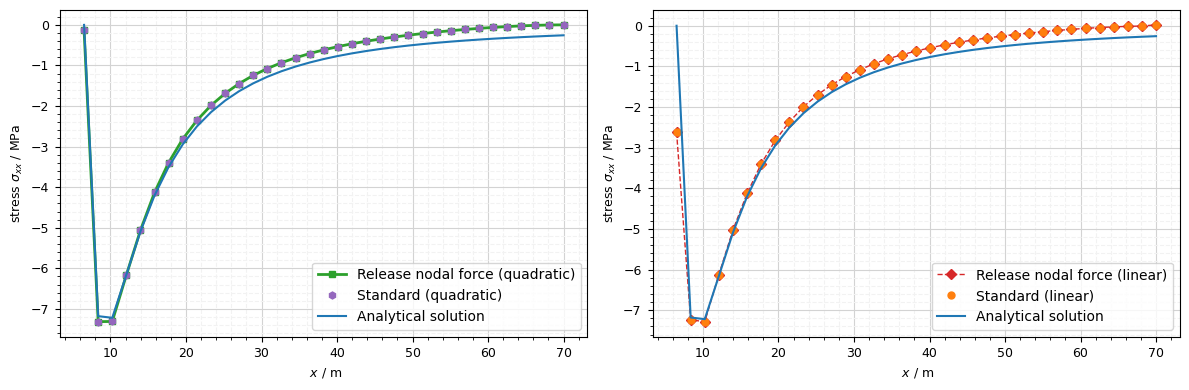

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ot.plot.lineplots.line(
    extracted_ms[-1],
    ot.variables.stress["xx"],
    ax=ax[0],
    fontsize=9,
    linewidth=0.8,
    color="C2",
    marker="s",
    markersize=5,
    label="Release nodal force (quadratic)",
)

ot.plot.lineplots.line(
    extracted_ms_linear[-1],
    ot.variables.stress["xx"],
    ax=ax[1],
    fontsize=9,
    linewidth=0.4,
    linestyle="dashed",
    marker="D",
    markersize=5,
    color="C3",
    label="Release nodal force (linear)",
)

ot.plot.lineplots.line(
    extracted_ms_std[-1],
    ot.variables.stress["xx"],
    ax=ax[0],
    fontsize=9,
    linewidth=0.4,
    marker="h",
    markersize=5,
    color="C4",
    linestyle="None",
    label="Standard (quadratic)",
)

ot.plot.lineplots.line(
    extracted_ms_std_linear[-1],
    ot.variables.stress["xx"],
    ax=ax[1],
    fontsize=9,
    linewidth=0.4,
    marker="o",
    markersize=5,
    color="C1",
    linestyle="None",
    label="Standard (linear)",
)


a = 6.5
sigma_t = -20  # MPa
sigma_x_a = np.asarray(
    [
        0.5 * (3.0 * a * a / (r * r) - 3 * a**4 / (r**4)) * sigma_t
        for r in np.linspace(6.5, 70.0, 35)
    ],
)
ax[0].plot(xs, sigma_x_a, color="C0", label="Analytical solution")
ax[0].legend()
ax[1].plot(xs, sigma_x_a, color="C0", label="Analytical solution")
ax[1].legend()
plt.show()

In the above two figures, the radial stress $\sigma_r$ profiles along the $\theta = 0^\circ$ axis, obtained using the standard approach, the release nodal force approach, and the analytical solution, are compared. The right-hand figure shows results using linear elements, while the left-hand figure displays results using quadratic elements.

At the arc, i.e., $r = 6.5$ m, the stress computed using linear elements shows a significant discrepancy of approximately 5.5 MPa compared to the analytical solution, which is zero. In contrast, the quadratic elements yield highly accurate stress results in the near field, i.e. around $r = 6.5$ m.

In both cases—whether using linear or quadratic elements—the standard approach and the release nodal force approach produce identical stress solutions.

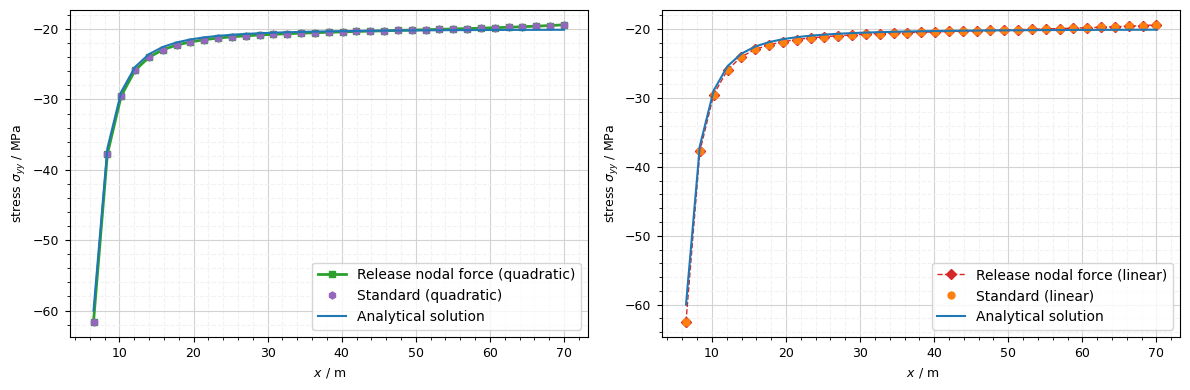

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ot.plot.lineplots.line(
    extracted_ms[-1],
    ot.variables.stress["yy"],
    ax=ax[0],
    fontsize=9,
    linewidth=0.8,
    color="C2",
    marker="s",
    markersize=5,
    label="Release nodal force (quadratic)",
)

ot.plot.lineplots.line(
    extracted_ms_linear[-1],
    ot.variables.stress["yy"],
    ax=ax[1],
    fontsize=9,
    linewidth=0.4,
    linestyle="dashed",
    marker="D",
    markersize=5,
    color="C3",
    label="Release nodal force (linear)",
)

ot.plot.lineplots.line(
    extracted_ms_std[-1],
    ot.variables.stress["yy"],
    ax=ax[0],
    fontsize=9,
    linewidth=0.4,
    marker="h",
    markersize=5,
    color="C4",
    linestyle="None",
    label="Standard (quadratic)",
)

ot.plot.lineplots.line(
    extracted_ms_std_linear[-1],
    ot.variables.stress["yy"],
    ax=ax[1],
    fontsize=9,
    linewidth=0.4,
    marker="o",
    markersize=5,
    color="C1",
    linestyle="None",
    label="Standard (linear)",
)


a = 6.5
sigma_t = -20  # MPa
sigma_y_a = np.asarray(
    [
        0.5 * (2 + a * a / (r * r) + 3 * a**4 / (r**4)) * sigma_t
        for r in np.linspace(6.5, 70.0, 35)
    ],
)
ax[0].plot(xs, sigma_y_a, color="C0", label="Analytical solution")
ax[0].legend()
ax[1].plot(xs, sigma_y_a, color="C0", label="Analytical solution")
ax[1].legend()
plt.show()

In the above two figures, the tangential stress $\sigma_{\theta}$ profiles along the $\theta = 0^\circ$ axis, obtained using the standard approach, the release nodal force approach, and the analytical solution, are compared. The right-hand figure shows results using linear elements, while the left-hand figure displays results using quadratic elements.

In both cases—whether using linear or quadratic elements—the standard approach and the release nodal force approach produce identical stress solutions that match the analytical solution, except at the arc (i.e., $r = 6.5$ m), where the computed stress shows a small, acceptable error.

In [23]:
ys = np.asarray(list(np.linspace(-857 + 6.5, -787.0, 35)))
y_axis = np.asarray([[0, y, 0] for y in ys])
extracted_ms_y = ot.MeshSeries.probe(ms, y_axis)
extracted_ms_y_linear = ot.MeshSeries.probe(ms_linear, y_axis)
extracted_ms_std_y = ot.MeshSeries.probe(ms_std, y_axis)
extracted_ms_std_y_linear = ot.MeshSeries.probe(ms_std_linear, y_axis)

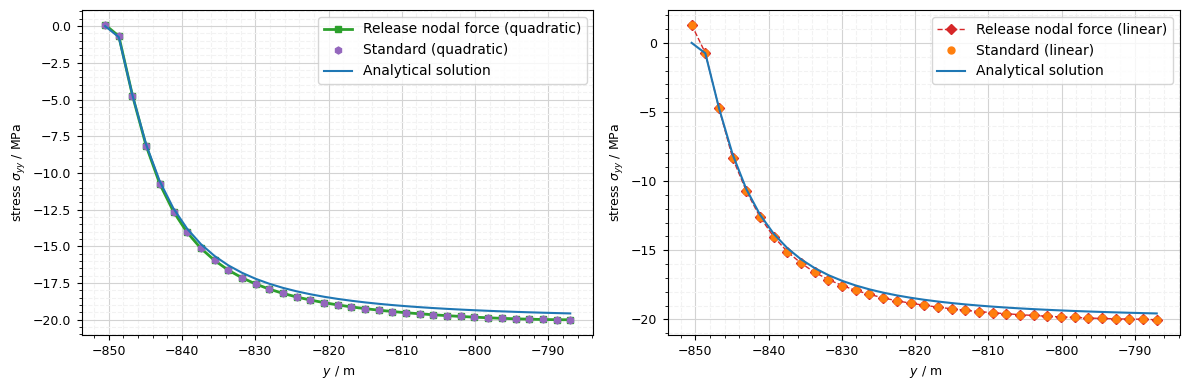

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ot.plot.lineplots.line(
    extracted_ms_y[-1],
    ot.variables.stress["yy"],
    ax=ax[0],
    fontsize=9,
    linewidth=0.8,
    color="C2",
    marker="s",
    markersize=5,
    label="Release nodal force (quadratic)",
)

ot.plot.lineplots.line(
    extracted_ms_y_linear[-1],
    ot.variables.stress["yy"],
    ax=ax[1],
    fontsize=9,
    linewidth=0.4,
    linestyle="dashed",
    marker="D",
    markersize=5,
    color="C3",
    label="Release nodal force (linear)",
)

ot.plot.lineplots.line(
    extracted_ms_std_y[-1],
    ot.variables.stress["yy"],
    ax=ax[0],
    fontsize=9,
    linewidth=0.4,
    marker="h",
    markersize=5,
    color="C4",
    linestyle="None",
    label="Standard (quadratic)",
)

ot.plot.lineplots.line(
    extracted_ms_std_y_linear[-1],
    ot.variables.stress["yy"],
    ax=ax[1],
    fontsize=9,
    linewidth=0.4,
    marker="o",
    markersize=5,
    color="C1",
    linestyle="None",
    label="Standard (linear)",
)


a = 6.5
sigma_t = -20  # MPa
sigma_y_a = np.asarray(
    [
        0.5 * (2.0 - 5.0 * a * a / (r * r) + 3 * a**4 / (r**4)) * sigma_t
        for r in np.linspace(6.5, 70.0, 35)
    ],
)
ax[0].plot(ys, sigma_y_a, color="C0", label="Analytical solution")
ax[0].legend()
ax[1].plot(ys, sigma_y_a, color="C0", label="Analytical solution")
ax[1].legend()
plt.show()

In the two figures above, the radial stress $\sigma_r$ profiles along the $\theta = 90^\circ$ axis are similarly compared across the standard approach, the release nodal force approach, and the analytical solution. The same conclusion as above can be drawn.

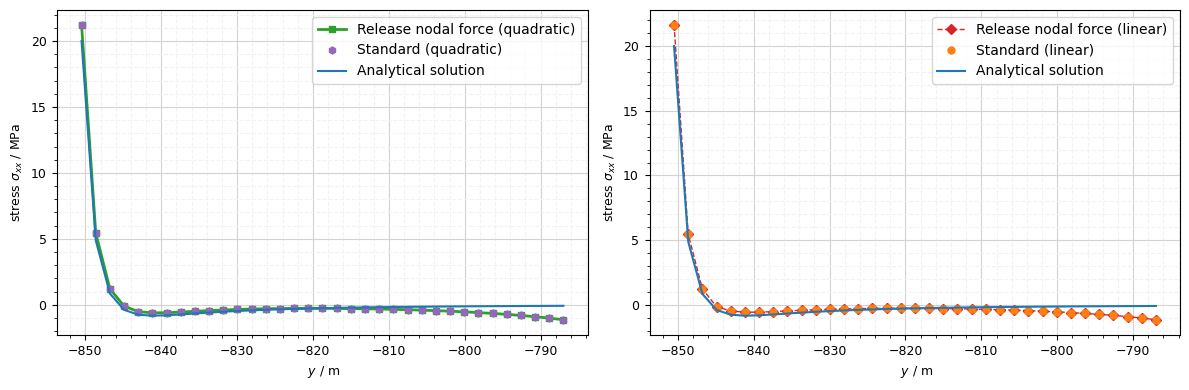

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ot.plot.lineplots.line(
    extracted_ms_y[-1],
    ot.variables.stress["xx"],
    ax=ax[0],
    fontsize=9,
    linewidth=0.8,
    color="C2",
    marker="s",
    markersize=5,
    label="Release nodal force (quadratic)",
)

ot.plot.lineplots.line(
    extracted_ms_y_linear[-1],
    ot.variables.stress["xx"],
    ax=ax[1],
    fontsize=9,
    linewidth=0.4,
    linestyle="dashed",
    marker="D",
    markersize=5,
    color="C3",
    label="Release nodal force (linear)",
)

ot.plot.lineplots.line(
    extracted_ms_std_y[-1],
    ot.variables.stress["xx"],
    ax=ax[0],
    fontsize=9,
    linewidth=0.4,
    marker="h",
    markersize=5,
    color="C4",
    linestyle="None",
    label="Standard (quadratic)",
)

ot.plot.lineplots.line(
    extracted_ms_std_y_linear[-1],
    ot.variables.stress["xx"],
    ax=ax[1],
    fontsize=9,
    linewidth=0.4,
    marker="o",
    markersize=5,
    color="C1",
    linestyle="None",
    label="Standard (linear)",
)


a = 6.5
sigma_t = -20  # MPa
sigma_x_a = np.asarray(
    [
        0.5 * (a * a / (r * r) - 3.0 * (a**4) / (r**4)) * sigma_t
        for r in np.linspace(6.5, 70.0, 35)
    ],
)
ax[0].plot(ys, sigma_x_a, color="C0", label="Analytical solution")
ax[0].legend()
ax[1].plot(ys, sigma_x_a, color="C0", label="Analytical solution")
ax[1].legend()
plt.show()

In the two figures above, the tangential stress $\sigma_{\theta}$ profiles along the $\theta = 90^\circ$ axis—obtained using the standard approach, the release nodal force approach, and the analytical solution—are compared. The figure on the right shows results using linear elements, while the figure on the left displays results using quadratic elements.

The figures show that the quadratic elements deliver more accurate tangential stress results than the linear elements do.

In [26]:
r = 6.5
h = -857
spoints = np.asarray(
    [
        [0, h + y, 0]
        for y in [
            r,
            r + 1,
            r + 2.5,
            r + 3.5,
            r + 8.5,
        ]
    ]
)
labels = [f"r = {point[1] -h:.1f} m" for i, point in enumerate(spoints)]

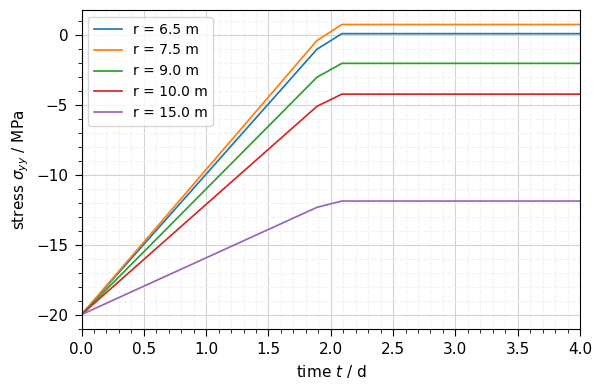

In [27]:
extracted_sp = ot.MeshSeries.probe(ms, spoints)
ot.plot.line(
    extracted_sp,
    "time",
    ot.variables.stress["yy"],
    labels=labels,
    figsize=(6, 4),
    fontsize=11,
    linewidth=0.5,
)
plt.xlim(0, 4)
plt.legend()

plt.grid(True)
plt.show()

The figure above shows the radial stress variation at different positions along the $\theta = 0^\circ$ axis.

Over time, the absolute stress values decrease from their initial value of 20 MPa, especially at the boundary ($r = 6.5\,\text{m}$), where the stress drops to nearly the expected value of zero.

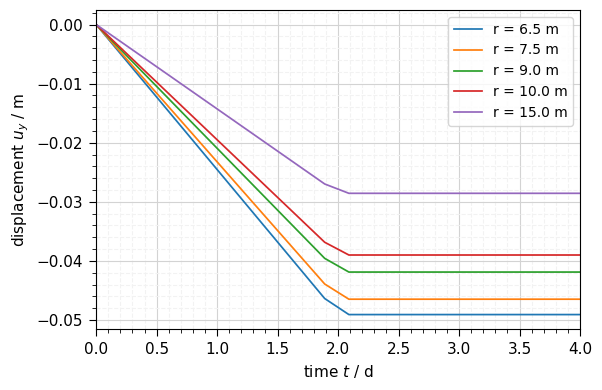

In [28]:
ot.plot.line(
    extracted_sp,
    "time",
    ot.variables.displacement["y"],
    labels=labels,
    figsize=(6, 4),
    fontsize=11,
    linewidth=0.5,
)
plt.xlim(0, 4)
plt.legend()

plt.grid(True)
plt.show()

The figure above shows the radial displacement variation at different positions along the $\theta = 0^\circ$ axis.

Over time, the absolute displacement values increase, particularly at the boundary ($r = 6.5\,\text{m}$), where the maximum displacement change occurs as expected.

#### 6. Simulation using element deactivation

For comparison, we also simulate the same problem using element deactivation.
In this case, the domain includes the hole, and the elements inside the hole are deactivated throughout the entire simulation. The stress values at their integration points of the deactivated elements are set to zero to ensure accurate extrapolation.

In [29]:
if not gmsh.isInitialized():
    gmsh.initialize(readConfigFiles=False)

gmsh.model.add("Mesh")

mesh_generator = MeshGenerator(gmsh_model=gmsh.model)
mesh_dir_with_hole = Path(out_dir, "Mesh", "Entire")
mesh_generator.generate_meshes(out_dir=mesh_dir_with_hole, with_cavern=True, order=2)

gmsh.finalize()

INFO:ogstools.meshes.gmsh_converter:Detected domain dimension of 2
INFO:ogstools.meshes.gmsh_converter:Found material IDs: [1 2]
INFO:ogstools.meshes.gmsh_converter:Renumbered to: [0 1]
INFO:ogstools.meshes.gmsh_converter:domain: UnstructuredGrid (0x767d876c16c0)
  N Cells:    3148
  N Points:   3082
  X Bounds:   0.000e+00, 7.000e+01
  Y Bounds:   -8.570e+02, -7.870e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   1
INFO:ogstools.meshes.gmsh_converter:bottom: UnstructuredGrid (0x767d87bd6c80)
  N Cells:    67
  N Points:   68
  X Bounds:   0.000e+00, 7.000e+01
  Y Bounds:   -8.570e+02, -8.570e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   2
INFO:ogstools.meshes.gmsh_converter:left: UnstructuredGrid (0x767d87bd4220)
  N Cells:    67
  N Points:   68
  X Bounds:   0.000e+00, 0.000e+00
  Y Bounds:   -8.570e+02, -7.870e+02
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   2
INFO:ogstools.meshes.gmsh_converter:right: UnstructuredGrid (0x767d87bd4640)
  N Cells:    40
  N Points:  

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 20%] Meshing curve 5 (Line)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 30%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 40%] Meshing curve 9 (Line)
Info    : [ 50%] Meshing curve 10 (Line)
Info    : [ 50%] Meshing curve 11 (Line)
Info    : [ 60%] Meshing curve 12 (Line)
Info    : [ 60%] Meshing curve 13 (Line)
Info    : [ 60%] Meshing curve 14 (Line)
Info    : [ 70%] Meshing curve 15 (Line)
Info    : [ 70%] Meshing curve 16 (Line)
Info    : [ 80%] Meshing curve 17 (Circle)
Info    : [ 80%] Meshing curve 18 (Circle)
Info    : [ 90%] Meshing curve 19 (Circle)
Info    : [ 90%] Meshing curve 20 (Circle)
Info    : [100%] Meshing curve 21 (Line)
Info    : [100%] Meshing curve 22 (Line)
Info    : Done meshing 1D (Wall 0.000819185s, CPU 0.001184s)
Info    : Mesh

In [30]:
pvd_ed = runBenchmark(
    project_file=release_project_file,
    out_dir=out_dir,
    prj_dir=prj_dir,
    output_prefix="kirsch_element_deactivation",
    mesh_dir=mesh_dir_with_hole,
    order=2,
    use_element_deactivation=True,
)

 ogs -o _out -m _out/Mesh/Entire _prj/kirsch_element_deactivation.prj
['ogs', '-o', '_out', '-m', '_out/Mesh/Entire', '_prj/kirsch_element_deactivation.prj']
Output prefix is kirsch_element_deactivation


In [31]:
ms_ed = ot.MeshSeries(pvd_ed).scale(time="d")

extracted_ms_ed_x = ot.MeshSeries.probe(ms_ed, probes)
extracted_ms_ed_y = ot.MeshSeries.probe(ms_ed, y_axis)

100%|██████████| 22/22 [00:00<00:00, 44.54it/s]


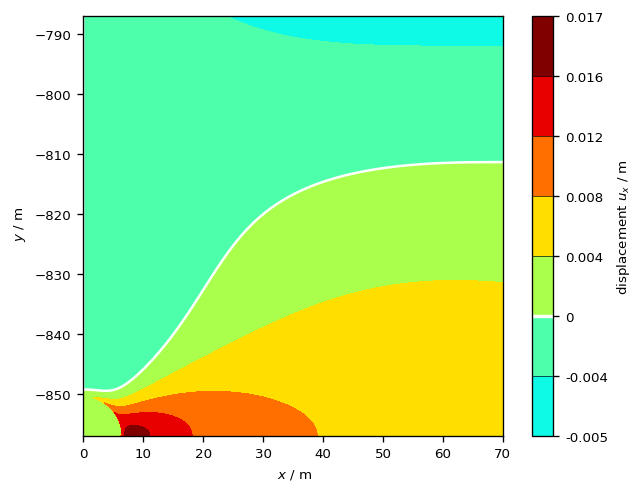

In [32]:
fig = ot.plot.contourf(
    ms_ed[-1],
    ot.variables.displacement["x"],
    figsize=(6, 4),
    fontsize=8,
    cmap="jet",
)

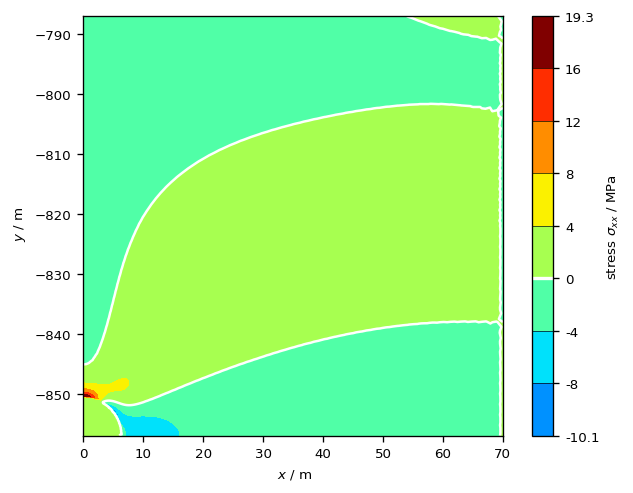

In [33]:
fig = ot.plot.contourf(
    ms_ed[-1],
    ot.variables.stress["xx"],
    figsize=(6, 4),
    fontsize=8,
    cmap="jet",
)

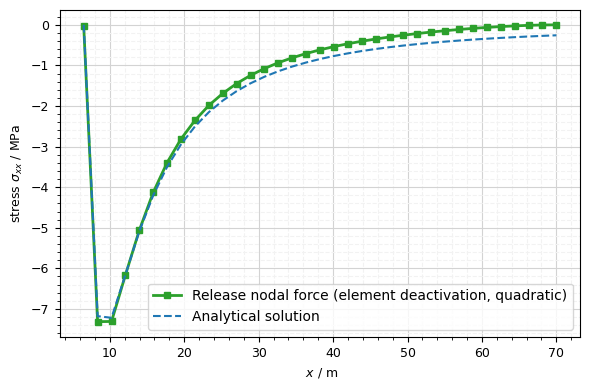

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ot.plot.lineplots.line(
    extracted_ms_ed_x[-1],
    ot.variables.stress["xx"],
    ax=ax,
    fontsize=9,
    linewidth=0.8,
    color="C2",
    marker="s",
    markersize=5,
    label="Release nodal force (element deactivation, quadratic)",
)

a = 6.5
sigma_t = -20  # MPa
sigma_x_a = np.asarray(
    [
        0.5 * (3.0 * a * a / (r * r) - 3 * a**4 / (r**4)) * sigma_t
        for r in np.linspace(6.5, 70.0, 35)
    ],
)
plt.plot(xs, sigma_x_a, color="C0", label="Analytical solution")
plt.legend()
plt.show()

In the above figure, the radial stress $\sigma_r$ profiles along the $\theta = 0^\circ$ axis, obtained using the release nodal force approach together with the element deactivation and the analytical solution, are compared.

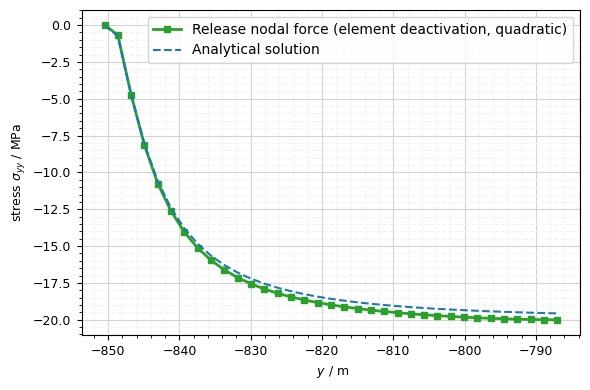

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ot.plot.lineplots.line(
    extracted_ms_ed_y[-1],
    ot.variables.stress["yy"],
    ax=ax,
    fontsize=9,
    linewidth=0.8,
    color="C2",
    marker="s",
    markersize=5,
    label="Release nodal force (element deactivation, quadratic)",
)

a = 6.5
sigma_t = -20  # MPa
sigma_y_a = np.asarray(
    [
        0.5 * (2.0 - 5.0 * a * a / (r * r) + 3 * a**4 / (r**4)) * sigma_t
        for r in np.linspace(6.5, 70.0, 35)
    ],
)
plt.plot(ys, sigma_y_a, color="C0", label="Analytical solution")
plt.legend()
plt.show()

In the above figure, the radial stress $\sigma_r$ profiles along the $\theta = 90^\circ$ axis, obtained using the release nodal force approach together with the element deactivation and the analytical solution, are compared.

#### 7. Conclusions

The implemented `ReleaseNodalForce` type boundary condition is verified using the classic example of Kirsch's problem.

Verification is carried out by analyzing Kirsch's problem using both the release nodal force approach and the standard approach. By comparing the solutions obtained from the standard approach and the analytical solution, the correctness of the present method and its implementation is validated.
In the near field, the numerical method yields highly accurate stress results.

In the far field, the numerical results show a small, acceptable error compared to the analytical solution, which is for an ideal model with an infinite domain.

This boundary condition can be used together with the element deactivation approach. In this case, the stress values in the deactivated element must be set to zero to ensure accurate stress extrapolation.

Additionally, the benchmark is evaluated using linear elements, which result in significant stress errors due extrapolation. Therefore, linear elements should be avoided in stress analyses to ensure accurate results.

# References